In [1]:
import pandas as pd

#df = pd.read_excel("Database_v2.1_part1.xlsx", nrows=5000)

df = pd.read_excel("Database_v2.1_part1.xlsx", nrows=20, header=None)
print(df)


                                                   0            1   \
0   Wu, Y., Fang, X., and Ji, J.: Global zircon U-...          NaN   
1   License: Creative Commons Attribution 4.0 Inte...          NaN   
2                                                 NaN          NaN   
3                                          Ref_number  Data_number   
4                                           REF-00001            1   
5                                           REF-00001            2   
6                                           REF-00001            3   
7                                           REF-00001            4   
8                                           REF-00001            5   
9                                           REF-00001            6   
10                                          REF-00001            7   
11                                          REF-00001            8   
12                                          REF-00001            9   
13                  

In [2]:
import pandas as pd

df = pd.read_excel("Database_v2.1_part1.xlsx", header=3)

print(df.shape)
print(df.head())

(673398, 24)
  Ref_number  Data_number Sample_number  isotope206Pb/238U  \
0  REF-00001            1           1-1                NaN   
1  REF-00001            2           1-2                NaN   
2  REF-00001            3           1-3                NaN   
3  REF-00001            4           1-4                NaN   
4  REF-00001            5           1-5                NaN   

   isotope206Pb/238U_σ  isotope207Pb/235U  isotope207Pb/235U_σ  \
0                  NaN                NaN                  NaN   
1                  NaN                NaN                  NaN   
2                  NaN                NaN                  NaN   
3                  NaN                NaN                  NaN   
4                  NaN                NaN                  NaN   

   isotope207Pb/206Pb  isotope207Pb/206Pb_σ  isotope208Pb/232Th  ...  \
0                 NaN                   NaN                 NaN  ...   
1                 NaN                   NaN                 NaN  ...   
2

In [3]:
target = "age207Pb/206Pb"
df[["age207Pb/206Pb"]].dropna().shape


(553368, 1)

In [4]:
print(df.columns.tolist())

['Ref_number', 'Data_number', 'Sample_number', 'isotope206Pb/238U', 'isotope206Pb/238U_σ', 'isotope207Pb/235U', 'isotope207Pb/235U_σ', 'isotope207Pb/206Pb', 'isotope207Pb/206Pb_σ', 'isotope208Pb/232Th', 'isotope208Pb/232Th_σ', 'age206Pb/238U', 'age206Pb/238U_σ', 'age207Pb/235U', 'age207Pb/235U_σ', 'age207Pb/206Pb', 'age207Pb/206Pb_σ', 'age208Pb/232Th', 'age208Pb/232Th_σ', 'Instrument', 'Reference_material', 'Lithology', 'Longitude', 'Latitude']


In [5]:
df.notna().sum().sort_values(ascending=False)

Ref_number              673398
Data_number             673398
Sample_number           673379
Instrument              662868
age206Pb/238U           630110
age206Pb/238U_σ         618946
Lithology               612807
age207Pb/206Pb          553368
age207Pb/206Pb_σ        544627
isotope206Pb/238U       540626
isotope206Pb/238U_σ     535789
Longitude               491557
Latitude                491557
isotope207Pb/235U       480896
isotope207Pb/235U_σ     476279
isotope207Pb/206Pb      469072
isotope207Pb/206Pb_σ    464099
age207Pb/235U           441804
age207Pb/235U_σ         431812
Reference_material      431234
isotope208Pb/232Th       84089
isotope208Pb/232Th_σ     83676
age208Pb/232Th           73467
age208Pb/232Th_σ         73373
dtype: int64

In [7]:
features = [
    "isotope206Pb/238U",
    "isotope207Pb/235U",
    "isotope207Pb/206Pb"
]

target = "age207Pb/206Pb"

df_model = df[features + [target]].dropna()

df_model = df_model[
    (df_model[target] >= 0) &
    (df_model[target] <= 4600)
]

print(df_model.shape)

(352693, 4)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf = 4,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15}


In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf = 4,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

## the best of the training

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("R²:", r2)

MAE: 25.049848241744616
R²: 0.9794655807278514


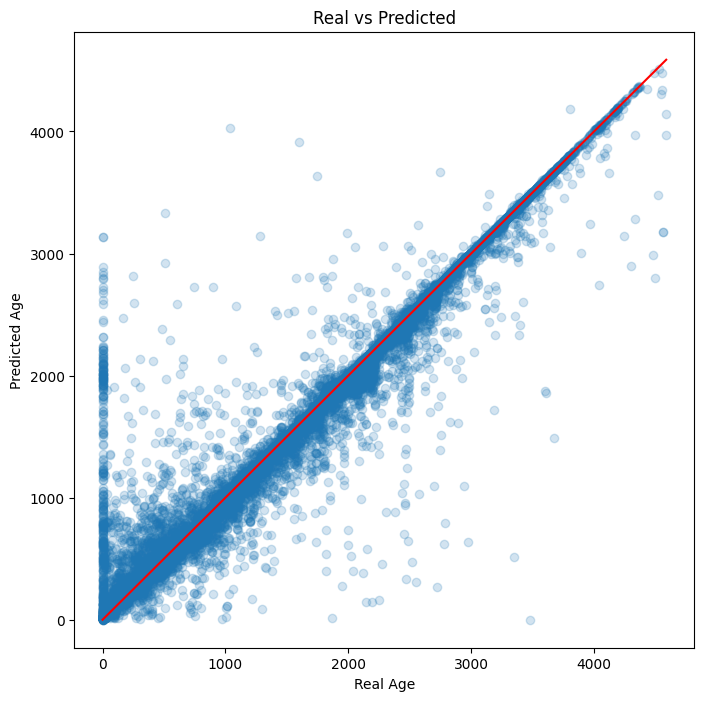

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(y_test, preds, alpha=0.2)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Real vs Predicted")

plt.show()